In [147]:
import numpy as np
import pandas as pd

# Generate data for NARX 1 & NARX 2

## NARX 1

In [148]:
# NARX 1

def sim_narx1(n, sigmau, sigmaw, seed):
    y= np.zeros((n, 2))
    np.random.seed(seed)
    u = np.random.normal(0, sigmau, n)
    w = np.random.normal(0, sigmaw, (n, 2))

    y[1, :] = w[1, :] # k = 0

    for k in range(1, n - 1):
        y[k + 1, 0] = 0.5 * y[k - 1, 1] + np.sin(y[k, 1]) + 0.3 * u[k - 1] + w[k + 1, 0]

        y[k + 1, 1] = 0.5 * y[k - 1, 0] + np.sin(y[k, 0]) + 0.2 * u[k] + w[k + 1, 1]
    
    return u, y


#NARX 2
def sim_narx2(n, sigmau, sigmaw, seed):
    np.random.seed(seed)
    u = np.random.normal(0, sigmau, (n, 2))
    y = np.zeros((n, 2))
    w = np.random.normal(0, sigmaw, (n, 2))

    # definicao de y[1] e y[2]
    y[1, :] = w[1, :] # k = 0
    y[2, :] = u[1, :] + w[2, :] # k = 1

    for k in range(2, n - 1):
        top1 = (y[k, 0] * y[k - 1, 0] * y[k - 2, 0] * (y[k - 2, 0] - 1) * u[k - 1, 1]) + u[k, 1]
        bot1 = 1 + (y[k - 1, 1]**2) + (y[k - 2, 1]**2)
        y[k + 1, 0] = (top1 / bot1) + w[k + 1, 0]

        top2 = (y[k, 1] * y[k - 1, 1] * y[k - 2, 1] * (y[k - 2, 1] - 1) * u[k - 1, 0]) + u[k, 0]
        bot2 = 1 + (y[k - 1, 0]**2) + (y[k - 2, 0]**2)
        y[k + 1, 1] = (top2 / bot2) + w[k + 1, 1]
    
    return u, y

# Pre-processing

In [244]:
u_narx1, y_narx1 = sim_narx1(1000, 1, 0.1, 42) #sigmau needs to be at least =1 bc if it's smaller y1 & y2 are too correlated
u_narx2, y_narx2 = sim_narx2(5000, 0.3, 0.005, 42) 

In [245]:
#turn generated data into dataframe so it's easier to use later on
import pandas as pd

def narx1_to_dataframe(u, y):
    df = pd.DataFrame({
        "u": u_narx1,
        "y1": y_narx1[:, 0],
        "y2": y_narx1[:, 1]
    })
    return df

def narx2_to_dataframe(u, y):
    df2 = pd.DataFrame({
        "u1": u_narx2[:, 0],
        "u2": u_narx2[:, 1],
        "y1": y_narx2[:, 0],
        "y2": y_narx2[:, 1],
    })
    return df2

df = narx1_to_dataframe(u_narx1, y_narx1)
df2 = narx2_to_dataframe(u_narx2, y_narx2)

# Parameters selection approach

## NARX1

In [33]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

#use PACF to determine na
#downside of PACF is that it won't be able to see the inetraction between y1 & y2 BUT will give us idea of candidates to use for na in our grid search

pacf_y1 = pacf(df["y1"], nlags=10)
pacf_y2 = pacf(df["y2"], nlags=10)

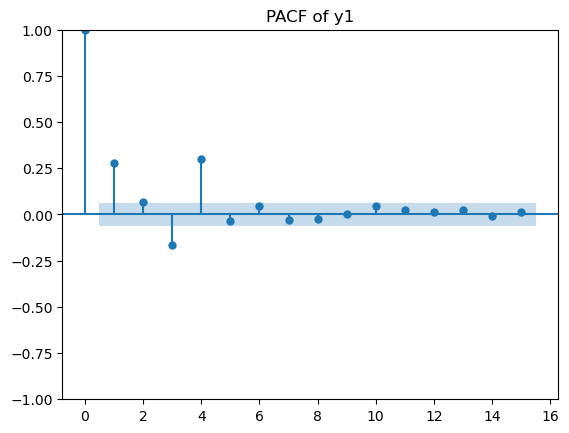

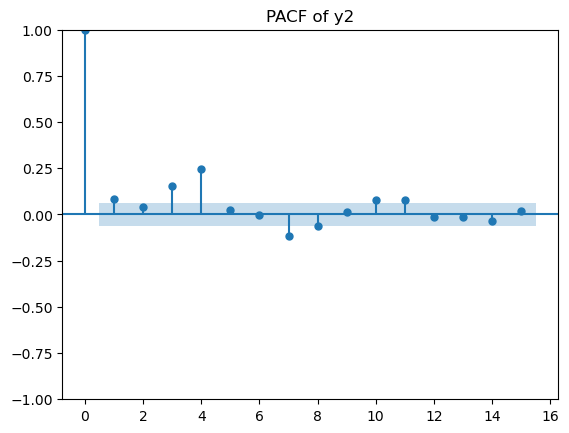

In [35]:
plot_pacf(df["y1"], lags=15)
plt.title("PACF of y1")
plt.show()

plot_pacf(df["y2"], lags=15)
plt.title("PACF of y2")
plt.show()


#PACF of y1: ~lag 4 seems to be significant (2 is borderline, but still some influence)
#PACF of y2: ~lag 4 seems to be significant (1-2 are small though)
#our candidates for na (output lag) -> [1:4] but PACF only takes individual effect of y(i) on itself -> we need to see the effect of y1 on y2 and vice versa

In [36]:
#for u, we can't use PACF. Instead, we'll use cross-correlation -> will give us candidates to use in grid seach
#we create our own ccf function because the statsmodels.ccf function calculates the corr(x(k−ℓ),y(k)) but the one we need is corr(x(k−ℓ),y(k+1)) 
#but statsmodels.ccf doesn't handle shifting the data

def compute_ccf(u, y, max_lag):
    ccf_values = []
    
    #we shift y by one so we look at y(k+1) and u(k)
    u = u[:-1]
    y = y[1:]
    
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = np.corrcoef(u, y)[0,1]
        else:
            corr = np.corrcoef(u[:-lag], y[lag:])[0,1]
        
        ccf_values.append(corr)
    
    return np.array(ccf_values)

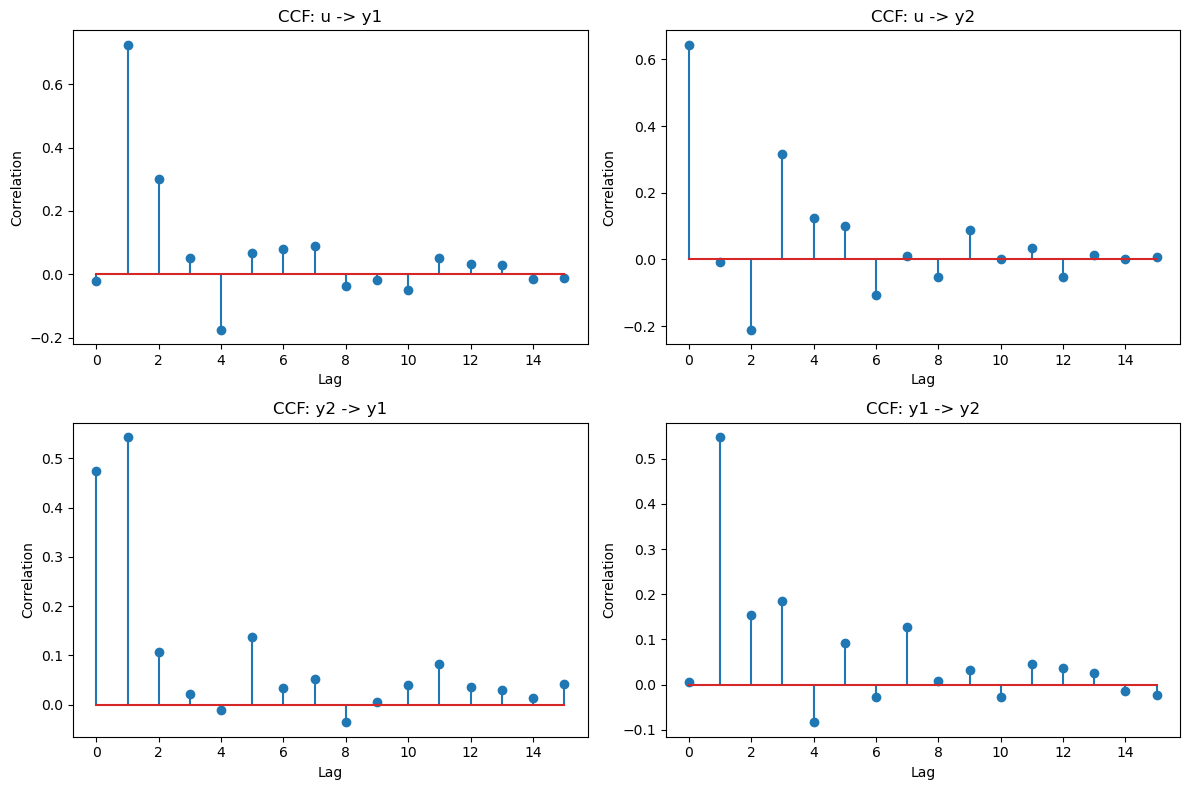

In [42]:
u  = df["u"].values
y1 = df["y1"].values
y2 = df["y2"].values

ccf_u_y1 = compute_ccf(u, y1, max_lag=15)
ccf_u_y2 = compute_ccf(u, y2, max_lag=15)
ccf_y2_y1 = compute_ccf(y2, y1, max_lag=15)
ccf_y1_y2 = compute_ccf(y1, y2, max_lag=15)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# u → y1
axes[0, 0].stem(range(len(ccf_u_y1)), ccf_u_y1)
axes[0, 0].set_title("CCF: u -> y1")
axes[0, 0].set_xlabel("Lag")
axes[0, 0].set_ylabel("Correlation")

# u → y2
axes[0, 1].stem(range(len(ccf_u_y2)), ccf_u_y2)
axes[0, 1].set_title("CCF: u -> y2")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Correlation")

# y2 → y1
axes[1, 0].stem(range(len(ccf_y2_y1)), ccf_y2_y1)
axes[1, 0].set_title("CCF: y2 -> y1")
axes[1, 0].set_xlabel("Lag")
axes[1, 0].set_ylabel("Correlation")

# y1 → y2
axes[1, 1].stem(range(len(ccf_y1_y2)), ccf_y1_y2)
axes[1, 1].set_title("CCF: y1 -> y2")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()


#-----------------
#ccf will help us choose d (delay), na (output lag) and nb (input lag)
#first lag where correlation becomes significative -> delay

#u -> y1 -> 1st significant effect at lag 1 (with secondary effect at lag 2)--> nb_y1 = [1, 2]
#u -> y2 -> first significant effect at lag 0 (dominant) --> nb_y2 = [0, 2, 3]
# --> nb ~ [1, 2, 3]

#-----------------
#y2 -> y1 -> significant effects at lags 0 and 1 --> na_y1 ~ = [0, 1]
#y1 -> y2 -> significant effects at lag 1 --> na_y2 ~ = [1, 2, 3]
## --> delay = d ~ [0,1], na ~ = [1, 2, 3, 4] (take 4 to nt be too strict)



# NARX2